# Week 10 — Day 2 — Session 4

## Building a CNN and Understanding Every Layer


### Session Goal

The goal of this session is **not** to introduce more CNN architectures.

Instead, we will build a small CNN step by step and understand exactly what happens to the image at every stage:

```text
Image
  ↓
Convolution
  ↓
Activation
  ↓
Pooling
  ↓
Convolution
  ↓
Activation
  ↓
Pooling
  ↓
Flatten
  ↓
Linear
  ↓
Prediction
```

The central question throughout the session is:

> **What happens to the data at each layer?**

---

# Learning Objectives

By the end of this session, students should be able to:

1. Represent an image as a PyTorch tensor.
2. Explain the meaning of `in_channels`, `out_channels`, `kernel_size`, `stride`, and `padding`.
3. Calculate the output shape of a `Conv2d` layer.
4. Explain what pooling does and why it is used.
5. Calculate the tensor shape after several CNN layers.
6. Explain why `Flatten` is needed before a fully connected layer.
7. Build a simple CNN in PyTorch.
8. Explain what parameters are learned during CNN training.
9. Connect convolutional filters to the gradient-descent concepts from Weeks 8–9.
10. Understand the complete forward-pass pipeline of a CNN.

---

# 1. From Image to Tensor

Start with a familiar example:

> Suppose we want to classify images of airplanes, cars, birds, cats, etc.

We will use **CIFAR-10**.

Each CIFAR-10 image has:

$$
32\times32
$$

pixels and:

$$
3
$$

color channels.

Therefore:

$$
\boxed{3\times32\times32}
$$

in PyTorch's channel-first representation.

---

## 1.1 RGB Image

Conceptually:

```text
RGB Image

        32
   ┌──────────┐
32 │          │
   │   Image  │
   │          │
   └──────────┘
```

But the image actually contains three channels:

```text
Red Channel
    +
Green Channel
    +
Blue Channel
```

So:

$$
3\times32\times32
$$

---

# 1.2 A Batch of Images

Neural networks normally process multiple images together.

Suppose:

```python
batch_size = 64
```

Then the input tensor is:

```text
[64, 3, 32, 32]
```

The four dimensions mean:

```text
[Batch, Channels, Height, Width]
```

or:

$$
[B,C,H,W]
$$

---

## Quick Check


> What does `[128, 3, 32, 32]` mean?

Answer:

* 128 images
* 3 channels
* 32 pixels high
* 32 pixels wide

---

# 2. Build the CNN One Layer at a Time

Instead of showing the complete model immediately, construct it one layer at a time.

---

# 2.1 First Convolution

Start with:

```python
nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)
```


> What does each number mean?

---

## `in_channels=3`

The input is RGB:

$$
3
$$

channels.

---

## `out_channels=16`

We want:

$$
16
$$

filters.

Therefore:

$$
\boxed{
16\text{ filters}
\rightarrow
16\text{ feature maps}
}
$$

---

## `kernel_size=3`

Each filter looks at a:

$$
3\times3
$$

spatial region.

---

## `stride=1`

The filter moves one pixel at a time.

---

## `padding=1`

We add one layer of padding around the image.

---

# 2.2 Calculate the Output Size

Use:

$$
O=
\left\lfloor
\frac{N+2P-K}{S}
\right\rfloor+1
$$

For this example:

$$
N=32
$$

$$
P=1
$$

$$
K=3
$$

$$
S=1
$$

Therefore:

$$
O=
\frac{32+2(1)-3}{1}+1
$$

$$
O=32
$$

The spatial dimensions do not change.

But the number of channels changes from 3 to 16.

Therefore:

```text
Input:

[64, 3, 32, 32]

        ↓ Conv2d

Output:

[64, 16, 32, 32]
```

---

# 2.3 How Many Parameters?

This is a good opportunity to reinforce the previous section.

Each filter has:

$$
3\times3\times3=27
$$

weights.

We have 16 filters:

$$
27\times16=432
$$

weights.

If bias is enabled:

$$
432+16=448
$$

parameters.

Therefore:

```python
nn.Conv2d(3, 16, 3, padding=1)
```

has:

$$
\boxed{448}
$$

trainable parameters.

---

# 2.4 Add ReLU

Now:

```python
nn.ReLU()
```

The shape does **not** change.

```text
[64, 16, 32, 32]
        ↓
      ReLU
        ↓
[64, 16, 32, 32]
```

ReLU:

$$
f(x)=\max(0,x)
$$

Its role is to introduce non-linearity.

---

# 3. Add Max Pooling


Now add:

```python
nn.MaxPool2d(
    kernel_size=2,
    stride=2
)
```

The important idea:

> Pooling reduces spatial resolution.

Suppose the input is:

```text
32 × 32
```

After:

```text
2 × 2 Max Pooling
Stride = 2
```

we get:

```text
16 × 16
```

Therefore:

```text
[64, 16, 32, 32]
          ↓
       MaxPool
          ↓
[64, 16, 16, 16]
```

Notice:

> The number of channels does not change.

Only the spatial dimensions change.

---

# 3.1 What Does Max Pooling Do?

Consider:

$$
\begin{bmatrix}
2&5\\
1&3
\end{bmatrix}
$$

Max pooling produces:

$$
5
$$

So:

```text
2 5
1 3

 ↓

5
```

The layer keeps the strongest activation in the region.

---

# 3.2 Why Do We Use Pooling?

Three important reasons:

### I) Reduce spatial dimensions

```text
32 × 32
   ↓
16 × 16
```

### II) Reduce computation

Smaller feature maps mean fewer subsequent computations.

### III) Introduce some spatial robustness

A feature can move slightly without completely changing the representation.

---

# 4. Second Convolution

Now add:

```python
nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=1
)
```

Our current shape is:

```text
[64, 16, 16, 16]
```

The convolution produces:

```text
[64, 32, 16, 16]
```

Why?

Because:

```text
16 input channels
       ↓
32 filters
       ↓
32 output feature maps
```

---

# 4.1 The Important Pattern

The CNN is gradually transforming:

```text
RGB pixels
    ↓
16 features
    ↓
32 features
```

We are trading spatial resolution for richer feature representations.

A simplified view:

```text
Spatial Size          Channels

32 × 32                  3
   ↓
32 × 32                 16
   ↓
16 × 16                 16
   ↓
16 × 16                 32
```

---

# 5. Second Pooling Layer

Add:

```python
nn.MaxPool2d(2)
```

Therefore:

```text
[64, 32, 16, 16]

        ↓

[64, 32, 8, 8]
```

At this point, our CNN has transformed:

$$
3\times32\times32
$$

into:

$$
32\times8\times8
$$

---

# 6. The Complete CNN So Far

**Time: 35–45 minutes**

Now put everything together.

```python
model = nn.Sequential(

    nn.Conv2d(
        3, 16,
        kernel_size=3,
        padding=1
    ),

    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Conv2d(
        16, 32,
        kernel_size=3,
        padding=1
    ),

    nn.ReLU(),

    nn.MaxPool2d(2)
)
```

Let's trace the tensor:

```text
Input
[64, 3, 32, 32]

        ↓

Conv2d(3 → 16)
[64, 16, 32, 32]

        ↓

ReLU
[64, 16, 32, 32]

        ↓

MaxPool
[64, 16, 16, 16]

        ↓

Conv2d(16 → 32)
[64, 32, 16, 16]

        ↓

ReLU
[64, 32, 16, 16]

        ↓

MaxPool
[64, 32, 8, 8]
```

This is the point where students should be able to **read the architecture as a sequence of transformations**.

---

# 7. Flatten

We now have:

$$
32\times8\times8
$$

features per image.

Calculate:

$$
32\times8\times8=2048
$$

Therefore:

```text
[64, 32, 8, 8]
        ↓
     Flatten
        ↓
[64, 2048]
```

---

# 7.1 Why Do We Need Flatten?

Convolutional layers work with spatial structure:

```text
Channels × Height × Width
```

But a fully connected layer expects a vector:

```text
Number of Features
```

So we convert:

$$
32\times8\times8
$$

into:

$$
2048
$$

---

# 8. Final Classification Layer

CIFAR-10 has:

$$
10
$$

classes.

Therefore:

```python
nn.Linear(
    2048,
    10
)
```

produces:

```text
[64, 2048]
       ↓
Linear
       ↓
[64, 10]
```

Each image now has 10 output values.

Conceptually:

```text
Class 0 → airplane
Class 1 → automobile
Class 2 → bird
...
Class 9 → truck
```

---

# 9. Complete CNN Architecture

Our complete model is:

In [ ]:
from torch import nn

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(

            nn.Conv2d(
                3, 16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(
                32 * 8 * 8,
                10
            )
        
        )


    def forward(self, x):

        x = self.layers(x)

        return x


In [1]:
from torch import nn

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3, 16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                32 * 8 * 8,
                10
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# 10. Visualize the Complete Pipeline

Create a simple mental model:

```text
                    CIFAR-10 IMAGE
                     3 × 32 × 32
                          │
                          ▼
                 ┌─────────────────┐
                 │ Conv 3×3        │
                 │ 16 filters      │
                 └─────────────────┘
                          │
                    16 × 32 × 32
                          │
                          ▼
                       ReLU
                          │
                          ▼
                     MaxPool
                          │
                    16 × 16 × 16
                          │
                          ▼
                 ┌─────────────────┐
                 │ Conv 3×3        │
                 │ 32 filters      │
                 └─────────────────┘
                          │
                    32 × 16 × 16
                          │
                          ▼
                       ReLU
                          │
                          ▼
                     MaxPool
                          │
                     32 × 8 × 8
                          │
                          ▼
                      Flatten
                          │
                        2048
                          │
                          ▼
                       Linear
                          │
                          ▼
                     10 Classes
```

---

# 11. What Is the Network Actually Learning?


Now connect everything back to Weeks 8 and 9.

Question:

> **Are we manually telling the first convolution to detect edges?**

No.

> **Are we manually telling the second convolution to detect textures?**

No.

So what happens?

The filters are initialized with some initial values.

Then training changes them.

---

# 11.1 Random Initialization

Initially:

```text
Filter
↓
Random-ish weights
↓
Poor feature detection
```

The network makes poor predictions.

That produces a loss.

---

# 11.2 Loss

Suppose the correct class is:

```text
Cat
```

but the network predicts:

```text
Dog
```

The loss is high.

Then backpropagation calculates:

$$
\frac{\partial L}{\partial W}
$$

for the network's weights.

This includes the convolutional filters.

---

# 11.3 Update the Filters

Gradient descent updates them:

$$
W_{\text{new}}
= W_{\text{old}}
-\eta
\frac{\partial L}{\partial W}
$$

Therefore:

```text
Image
  ↓
CNN
  ↓
Prediction
  ↓
Loss
  ↓
Backpropagation
  ↓
Gradients
  ↓
Update convolution filters
```

---

# 11.4 The Key Connection to Week 9

You learned:

> **Gradient descent updates weights.**

Now we can say:

> **Convolution kernels are also learnable weights.**

Therefore, the exact same learning mechanism applies.

```text
Fully Connected Network:

Weights
   ↓
Gradient Descent
   ↓
Updated Weights


CNN:

Convolution Filters
   ↓
Gradient Descent
   ↓
Updated Filters
```

This is a very important conceptual bridge.

---

# 12. What Happens Across Layers?

Connect this to the visualization from the previous session.

A simplified intuition is:

```text
Input
  ↓
Pixels
  ↓
────────────────────
Early Convolution
  ↓
Edges
Color transitions
Simple patterns
────────────────────
  ↓
Middle Convolution
  ↓
Textures
Combinations
Shapes
────────────────────
  ↓
Deeper Representation
  ↓
Complex visual patterns
Object-related features
────────────────────
  ↓
Classification
```

Remember:

> This is a useful conceptual hierarchy, not a strict rule that every CNN follows exactly.

---

# 13. Visualizing Activations

This is an excellent short practical demonstration.

We can capture the output of a convolutional layer.

In [2]:
import torch

activations = {}

def hook_fn(module, input, output):

    activations["conv1"] = output.detach()

model = SimpleCNN()

model.features[0].register_forward_hook(hook_fn)

Then run an image:

In [3]:
image = torch.randn(3, 32, 32)

model.eval()

with torch.no_grad():

    output = model(image.unsqueeze(0))

feature_maps = activations["conv1"]

print(feature_maps.shape)

torch.Size([1, 16, 32, 32])


So one image produced:

$$
16
$$

feature maps.

---

# 13.1 Visualize Some Feature Maps

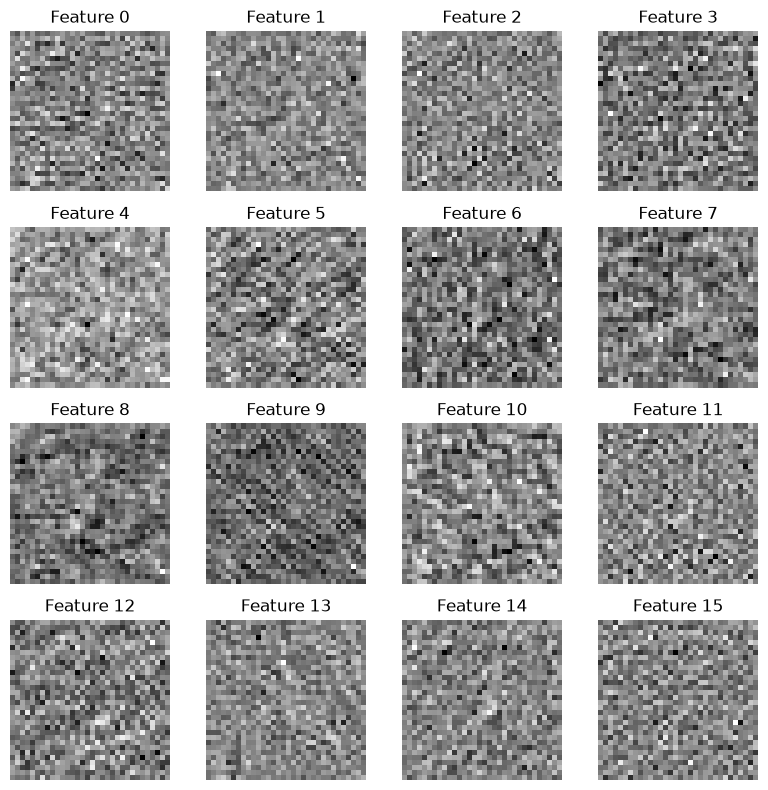

In [4]:
import matplotlib.pyplot as plt

feature_maps = feature_maps[0]

fig, axes = plt.subplots(
    4, 4,
    figsize=(8, 8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        feature_maps[i].cpu(),
        cmap="gray"
    )

    ax.set_title(f"Feature {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

---

# 14. From Filters to Features

Make the distinction explicit:

```text
Filter
  ↓
looks for a pattern
  ↓
Convolution
  ↓
Feature Map
  ↓
shows where the pattern occurs
```

This is a very useful sentence:

> **A filter defines what to look for; a feature map shows where it was found.**

---

# 15. Training the CNN

**Time: 60–75 minutes**

Now we actually train the network.

---

# 15.1 Loss Function

For CIFAR-10 classification:

```python
criterion = nn.CrossEntropyLoss()
```

---

# 15.2 Optimizer

Use Adam for simplicity:

```python
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)
```

Remind students:

> The optimizer updates **all learnable parameters**, including convolutional filters.

---

# 15.3 Training Loop

```python
for epoch in range(10):

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # -------------------------
        # Forward
        # -------------------------

        outputs = model(images)

        # -------------------------
        # Loss
        # -------------------------

        loss = criterion(
            outputs,
            labels
        )

        # -------------------------
        # Backward
        # -------------------------

        optimizer.zero_grad()

        loss.backward()

        # -------------------------
        # Update
        # -------------------------

        optimizer.step()
```

---

# 15.4 Connect the Code to the Mathematics

Students should be able to map:

```text
outputs = model(images)
```

to:

$$
\hat{y}=f_\theta(x)
$$

Then:

```text
loss = criterion(outputs, labels)
```

to:

$$
L(\hat{y},y)
$$

Then:

```text
loss.backward()
```

to:

$$
\frac{\partial L}{\partial\theta}
$$

And finally:

```text
optimizer.step()
```

to:

$$
\theta
\leftarrow
\theta-\eta\nabla_\theta L
$$

This is an important moment:

> **CNNs did not replace the learning process from Week 9. They changed the architecture and therefore changed what the learnable parameters represent.**

---

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
# ============================================================
# 2. Data (CIFAR-10)
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

In [8]:
# ============================================================
# 3. Model: SimpleCNN
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 32x32 → 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 → 16x16
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16x16 → 16x16
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 16x16 → 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)


In [9]:
# ============================================================
# 4. Loss & Optimizer
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch [1/10]  Loss: 1.5639
Epoch [2/10]  Loss: 1.2294
Epoch [3/10]  Loss: 1.1020
Epoch [4/10]  Loss: 1.0164
Epoch [5/10]  Loss: 0.9582
Epoch [6/10]  Loss: 0.9165
Epoch [7/10]  Loss: 0.8830
Epoch [8/10]  Loss: 0.8587
Epoch [9/10]  Loss: 0.8315
Epoch [10/10]  Loss: 0.8141
Training finished.


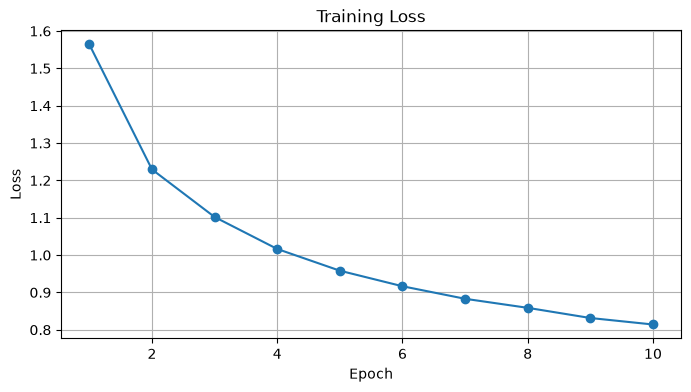

Test Accuracy: 66.74%
Feature maps shape: torch.Size([1, 16, 32, 32])


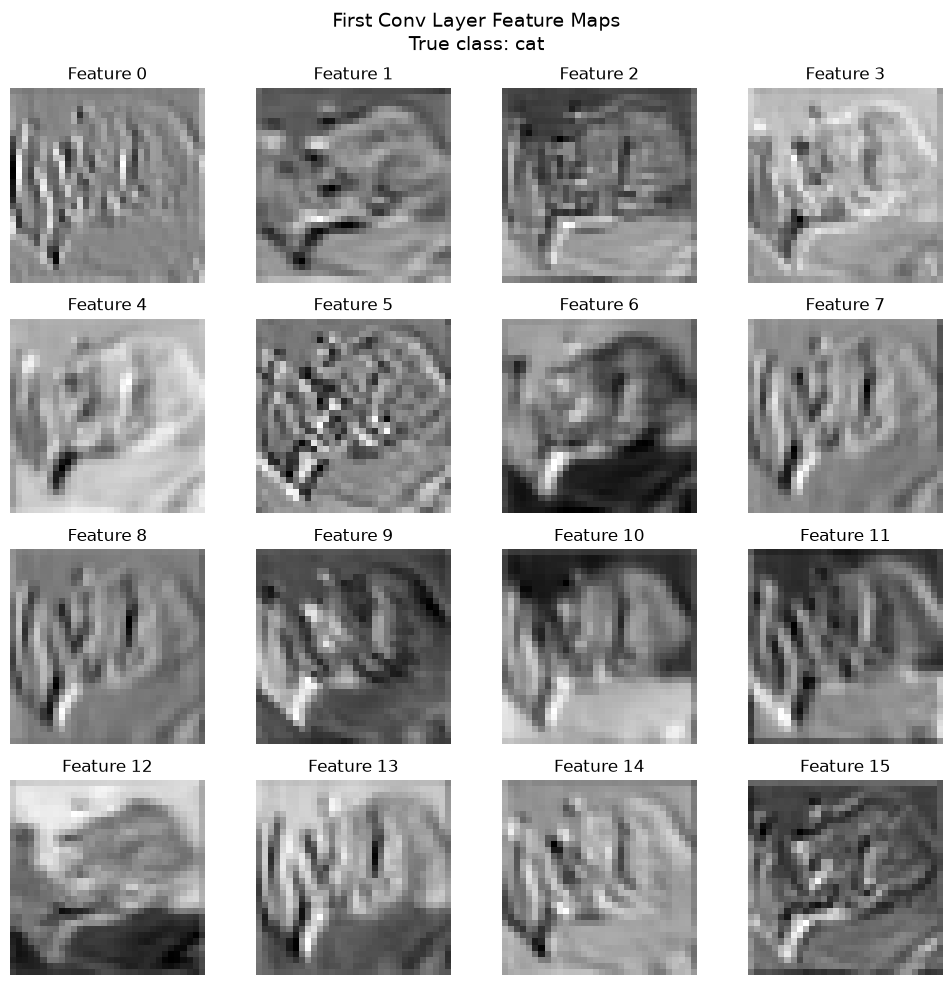

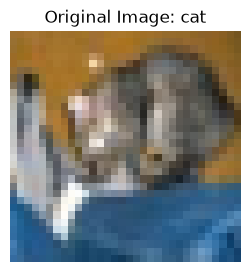

In [10]:
# ============================================================
# 5. Training Loop
# ============================================================
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}")

print("Training finished.")

# ============================================================
# 6. Plot training loss
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ============================================================
# 7. Evaluation on test set
# ============================================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images) #shape: (128,10)
        _, predicted = torch.max(outputs, 1) # shape: (128, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

# ============================================================
# 8. Feature Map Visualization (Hook)
# ============================================================
activations = {}

def hook_fn(module, input, output):
    activations["conv1"] = output.detach()

# Register hook on the first convolutional layer
hook = model.features[0].register_forward_hook(hook_fn)

# Take one sample image from the test set
sample_img, sample_label = test_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)   # (1, 3, 32, 32)

model.eval()
with torch.no_grad():
    _ = model(sample_img)

feature_maps = activations["conv1"]   # shape: (1, 16, 32, 32)
print("Feature maps shape:", feature_maps.shape)

# Remove the hook
hook.remove()

# Plot the 16 feature maps
feature_maps = feature_maps[0].cpu()  # (16, 32, 32)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="gray")
    ax.set_title(f"Feature {i}")
    ax.axis("off")

plt.suptitle(
    f"First Conv Layer Feature Maps\n"
    f"True class: {classes[sample_label]}",
    fontsize=14
)
plt.tight_layout()
plt.show()

# ============================================================
# 9. Optional: Show the original image
# ============================================================
# Denormalize for display
img_to_show = sample_img[0].cpu() * 0.5 + 0.5   # undo Normalize
img_to_show = img_to_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(3, 3))
plt.imshow(img_to_show)
plt.title(f"Original Image: {classes[sample_label]}")
plt.axis("off")
plt.show()

# 16. First Look at Overfitting

**Time: 75–85 minutes**

Do not yet teach all regularization techniques.

The goal here is simply to recognize the problem.

Suppose we observe:

```text
Epoch      Train Acc.      Val. Acc.

1             55%             50%
2             65%             57%
3             74%             62%
4             82%             64%
5             89%             63%
6             94%             62%
```

Ask:

> What is happening?

Training accuracy continues to increase.

But validation accuracy stops improving.

This is a classic sign of:

$$
\boxed{\text{Overfitting}}
$$

---

# 16.1 Visual Intuition

```text
Accuracy

100% |                Train
     |              /
     |            /
     |          /
     |        /
     |      /
     |    /──────── Validation
     |   /
     |  /
     | /
     +-------------------------
              Epoch
```

The model is becoming increasingly good at the training data without becoming better at unseen data.

---

# 16.2 Connect to Week 9

Ask:

> **What techniques did we learn in Week 9 to deal with overfitting?**

Expected answers:

* Weight decay
* Dropout
* Data-related techniques
* Learning-rate strategies
* Early stopping

Tell students:

> We will apply these ideas to CNNs in the next stage.

Do not spend significant time teaching them today.

---

# 17. Final Challenge


Given this architecture:

```text
Input: 32 × 32 × 3

Conv2D(
    3 → 16,
    kernel=3,
    stride=1,
    padding=1
)

ReLU

MaxPool2D(
    kernel=2,
    stride=2
)

Conv2D(
    16 → 32,
    kernel=3,
    stride=1,
    padding=1
)

ReLU

MaxPool2D(
    kernel=2,
    stride=2
)

Flatten

Linear(
    ? → 10
)
```

Fill in the missing number.

---

## Step 1

Input:

$$
3\times32\times32
$$

After first convolution:

$$
16\times32\times32
$$

---

## Step 2

After first pooling:

$$
16\times16\times16
$$

---

## Step 3

After second convolution:

$$
32\times16\times16
$$

---

## Step 4

After second pooling:

$$
32\times8\times8
$$

---

## Step 5

Flatten:

$$
32\times8\times8
=2048
$$

Therefore:

```python
nn.Linear(2048, 10)
```

---

# 18. Final Mental Model

End the session with this:

```text
                     IMAGE
                       │
                       ▼
                ┌─────────────┐
                │ Convolution │
                │ Learnable   │
                │ Filters     │
                └─────────────┘
                       │
                       ▼
                 Feature Maps
                       │
                       ▼
                     ReLU
                       │
                       ▼
                   Pooling
                       │
                       ▼
               Smaller Spatial
                 Representation
                       │
                       ▼
                More Convolution
                       │
                       ▼
              More Complex Features
                       │
                       ▼
                    Flatten
                       │
                       ▼
                    Linear
                       │
                       ▼
                 Prediction
                       │
                       ▼
                     Loss
                       │
                       ▼
                 Backpropagation
                       │
                       ▼
              Update CNN Filters
                       │
                       └──────────────┐
                                      │
                                      ▼
                                Next Iteration
```

---

# Key Takeaways

Students should be able to explain these statements without looking at their notes.

### 1. A CNN is still a neural network

It still has:

$$
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Weight Update}
$$

---

### 2. Convolutional filters are learnable weights

> The CNN learns the filters through gradient descent.

---

### 3. One filter produces one feature map

$$
\boxed{
N_{\text{filters}}
=N_{\text{output feature maps}}
}
$$

---

### 4. Pooling reduces spatial dimensions

```text
32 × 32
   ↓
16 × 16
   ↓
8 × 8
```

while typically preserving the number of channels.

---

### 5. Deeper layers combine simpler features

```text
Local patterns
      ↓
Textures / combinations
      ↓
Shapes
      ↓
Complex visual patterns
```

---

### 6. Flatten connects CNN features to classification

$$
32\times8\times8
\rightarrow
2048
\rightarrow
10
$$

---

### 7. CNN training is still optimization

$$
\boxed{
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Updated Filters}
}
$$

---

# Main Message

The most important thing for you to understand today is **not the PyTorch syntax**.

It is this:

> **A CNN takes an image, learns small local filters, applies those filters across the image, combines the resulting features through multiple layers, and uses gradient descent to learn which filters are useful for the task.**

Once this mental model is solid, concepts such as **ResNet, Batch Normalization, Data Augmentation, Weight Decay, Dropout, and Learning Rate Scheduling** will become much easier to understand rather than appearing as a collection of unrelated techniques.